In [1]:
from models.TIEModel import TIEModel
import torch, math
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from models.TIEUtils import collator, TemporalDataset
from torch.utils.data import DataLoader

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
NUM_EPOCHS = 20
ENC_LR = 5e-5
NONENC_LR = 1e-3
WARMUP_EPOCHS = 5
LOGGING_EPOCHS = 5
BASE_ENC_MODEL = "roberta-base"
HEADS = 6
WEIGHT_DECAY = 0.01
BATCH_SIZE = 16

In [3]:
cleandata_path = "D:\\GeoTKG\\cleandata\\tie\\"
train = TemporalDataset(cleandata_path + "combined.json")
eval = TemporalDataset(cleandata_path + "test.json")
#test = TemporalDataset(cleandata_path + "test.json")
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
eval_loader = DataLoader(eval, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)
#test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = TIEModel(base=BASE_ENC_MODEL, heads=HEADS).to(device)

for p in model.enc.parameters(): p.requires_grad = False

optimizer = AdamW([
        {"params": [p for n,p in model.named_parameters() if n.startswith("enc.")], "lr": ENC_LR},
        {"params": [p for n,p in model.named_parameters() if not n.startswith("enc.")], "lr": NONENC_LR},
    ], weight_decay=0.01)

steps_per_epoch = len(train_loader)
num_train_steps = steps_per_epoch * NUM_EPOCHS
num_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_train_steps)

scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

def make_optim(unfrozen: bool):
    groups = []
    if unfrozen:
        groups.append({"params": model.enc.parameters(), "lr": ENC_LR})
    else:
        # keep enc group empty or skip entirely; either is fine
        pass
    nonenc = [p for n, p in model.named_parameters() if not n.startswith("enc.")]
    groups.append({"params": nonenc, "lr": NONENC_LR})
    return AdamW(groups, weight_decay=WEIGHT_DECAY)

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.bias', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
global_step = 0
history = {#  Training
           "loss": [], "ner_loss":[], "et_loss":[], "ee_loss":[],
           #  Evaluation
           "ner_f1": [], "et_f1": [], "ee_f1": [], "eval_loss":[], "ner_eval_loss": [], "et_eval_loss": [], "ee_eval_loss": []}
enclr = []
nonenclr = []
for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    loss_sum = 0
    ner_loss_sum = 0
    et_loss_sum = 0
    ee_loss_sum = 0
    ration = 0
    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        ctx = (torch.autocast(device_type='cuda', dtype=torch.float16))
        with ctx:
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                ev_starts=batch["ev_starts"], ev_ends=batch["ev_ends"], ev_mask=batch["ev_mask"], e_sent_ids=batch["e_sent_ids"],
                ti_starts=batch["ti_starts"], ti_ends=batch["ti_ends"], ti_mask=batch["ti_mask"], t_sent_ids=batch["t_sent_ids"],
                ner_gold_labels=batch["ner_labels"],
                ev_ti_gold=batch["ev_ti_gold"],
                ee_rel_gold=batch["ee_triples"],
                ee_mask=batch["ee_mask"],
            )
            loss = out["loss"]
            loss_sum += loss.item()
            ner_loss_sum += out["ner_loss"].item()
            et_loss_sum += out["et_loss"].item()
            ee_loss_sum += out["ee_loss"].item()

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        prev_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        sched.step() if scaler.get_scale() <= prev_scale else None
        optimizer.zero_grad(set_to_none=True)
        global_step += 1

    print(f"Epoch {epoch+1} done. Avg Loss: {loss_sum / steps_per_epoch:.4f}")
    nonenclr.append(optimizer.param_groups[1]['lr'])
    enclr.append(optimizer.param_groups[0]['lr'])
    # ---- unfreeze after warmup epochs ----
    if epoch + 1 == WARMUP_EPOCHS:
        for p in model.enc.parameters():
            p.requires_grad = True
        # rebuild optimizer & scheduler for the remaining steps
        optimizer = make_optim(unfrozen=True)
        remaining_steps = steps_per_epoch * (NUM_EPOCHS - (epoch + 1))
        warmup_rem = 0
        sched = get_cosine_schedule_with_warmup(optimizer, warmup_rem, remaining_steps)

    # ---- validation ----
    if (epoch + 1) % LOGGING_EPOCHS == 0:
        model.eval()
        with torch.no_grad():
            batch_evaluation = model.evaluate_dataloader(eval_loader)
            history["ner_f1"].append(batch_evaluation["ner_f1"])
            history["et_f1"].append(batch_evaluation["et_f1"])
            history["ee_f1"].append(batch_evaluation["ee_f1"])
            history["eval_loss"].append(batch_evaluation["eval_loss"])
            history["ner_eval_loss"].append(batch_evaluation["ner_loss"])
            history["et_eval_loss"].append(batch_evaluation["et_loss"])
            history["ee_eval_loss"].append(batch_evaluation["ee_loss"])
            history["loss"].append(loss_sum / steps_per_epoch)
            history["ner_loss"].append(ner_loss_sum / steps_per_epoch)
            history["et_loss"].append(et_loss_sum / steps_per_epoch)
            history["ee_loss"].append(ee_loss_sum / steps_per_epoch)
        model.save(f"D:\\GeoTKG\\training\\results\\tie_model\\tie_model_epoch{epoch+1}.pt")
        print(f"EPOCH{epoch+1} \nNER F1={batch_evaluation['ner_f1']:.4f},  ET F1={batch_evaluation['et_f1']:.4f},  EE F1={batch_evaluation['ee_f1']:.4f}\nTrain Loss={loss_sum / steps_per_epoch:.4f},    Eval Loss={batch_evaluation['eval_loss']:.4f}\nNER Eval Loss={batch_evaluation['ner_loss']:.4f}, NER Train Loss={ner_loss_sum / steps_per_epoch:.4f}\nET Eval Loss={batch_evaluation['et_loss']:.4f},  ET Train Loss={et_loss_sum / steps_per_epoch:.4f}\nEE Eval Loss={batch_evaluation['ee_loss']:.4f},  EE Train Loss={ee_loss_sum / steps_per_epoch:.4f}")

d:\GeoTKG\venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1 done. Avg Loss: 5.3422
Epoch 2 done. Avg Loss: 2.5271
Epoch 3 done. Avg Loss: 2.2443
Epoch 4 done. Avg Loss: 2.1571
Epoch 5 done. Avg Loss: 2.1472


d:\GeoTKG\venv\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        DATE     0.7049    0.7245    0.7145      2403
    DURATION     0.1390    0.1722    0.1538       302
       EVENT     0.9302    0.8480    0.8872     16900
         SET     0.0000    0.0000    0.0000        16
        TIME     0.0000    0.0000    0.0000        47

   micro avg     0.8835    0.8198    0.8504     19668
   macro avg     0.3548    0.3489    0.3511     19668
weighted avg     0.8875    0.8198    0.8520     19668

              precision    recall  f1-score   support

         0.0     0.9915    0.8617    0.9220     88218
         1.0     0.1547    0.7745    0.2579      2883

    accuracy                         0.8589     91101
   macro avg     0.5731    0.8181    0.5899     91101
weighted avg     0.9650    0.8589    0.9010     91101

              precision    recall  f1-score   support

       AFTER     0.7996    0.8653    0.8311      6547
      BEFORE     0.2850    0.3549    0.3162       510
    CONTAINS     0.30

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


EPOCH10 
NER F1=0.9689,  ET F1=0.8686,  EE F1=0.8320
Train Loss=1.5734,    Eval Loss=1.3379
NER Eval Loss=0.0261, NER Train Loss=0.0832
ET Eval Loss=0.8349,  ET Train Loss=1.1133
EE Eval Loss=0.4769,  EE Train Loss=0.3770
Epoch 11 done. Avg Loss: 1.4803
Epoch 12 done. Avg Loss: 1.4003
Epoch 13 done. Avg Loss: 1.3256
Epoch 14 done. Avg Loss: 1.2595
Epoch 15 done. Avg Loss: 1.2132
              precision    recall  f1-score   support

        DATE     0.8863    0.9114    0.8986      2403
    DURATION     0.6997    0.7715    0.7339       302
       EVENT     0.9868    0.9863    0.9865     16900
         SET     0.6471    0.6875    0.6667        16
        TIME     0.4286    0.7021    0.5323        47

   micro avg     0.9670    0.9729    0.9699     19668
   macro avg     0.7297    0.8118    0.7636     19668
weighted avg     0.9685    0.9729    0.9706     19668

              precision    recall  f1-score   support

         0.0     0.9911    0.8120    0.8926     88218
         1.0     0.1

In [6]:
import json
with open("results/tie_model/history.json", "w") as f:
    json.dump(history, f, indent=2)

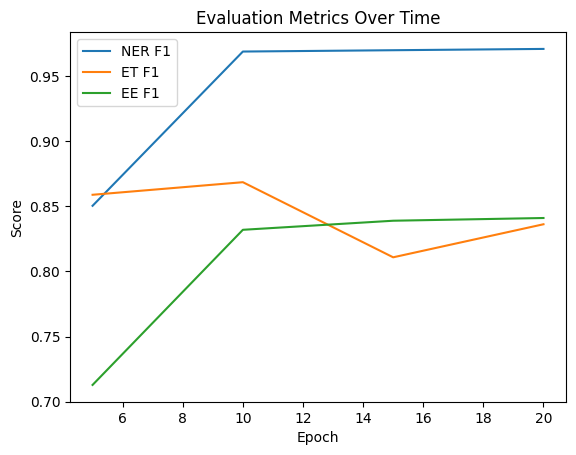

In [8]:
import matplotlib.pyplot as plt

x = list(range(5, 21, 5))

plt.plot(x, history["ner_f1"], label="NER F1")
plt.plot(x, history["et_f1"], label="ET F1")
plt.plot(x, history["ee_f1"], label="EE F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Evaluation Metrics Over Time")
plt.legend()
plt.show()

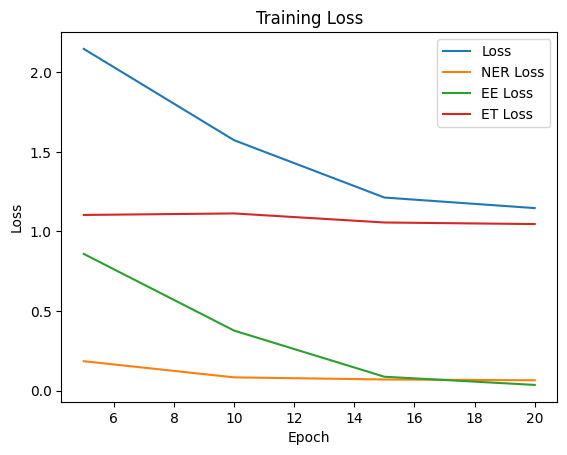

In [9]:
plt.plot(x, history["loss"], label="Loss")
plt.plot(x, history["ner_loss"], label="NER Loss")
plt.plot(x, history["ee_loss"], label="EE Loss")
plt.plot(x, history["et_loss"], label="ET Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

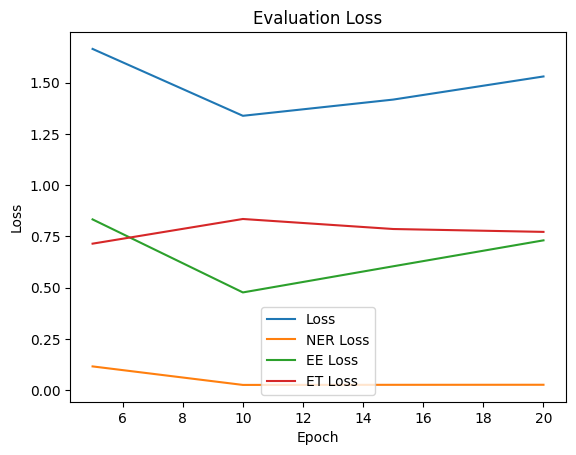

In [10]:
plt.plot(x, history["eval_loss"], label="Loss")
plt.plot(x, history["ner_eval_loss"], label="NER Loss")
plt.plot(x, history["ee_eval_loss"], label="EE Loss")
plt.plot(x, history["et_eval_loss"], label="ET Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evaluation Loss")
plt.show()

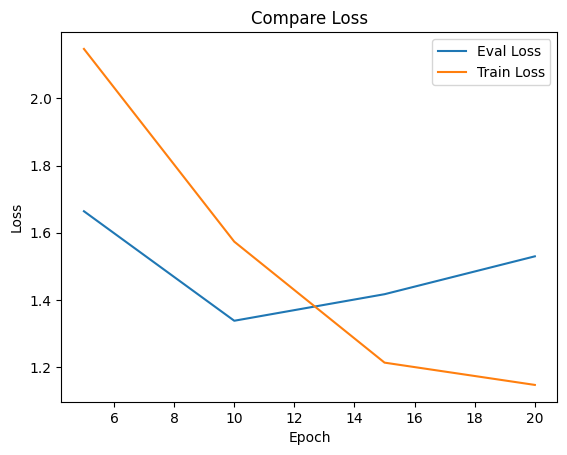

In [11]:
plt.plot(x, history["eval_loss"], label="Eval Loss")
plt.plot(x, history["loss"], label="Train Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Compare Loss")
plt.show()

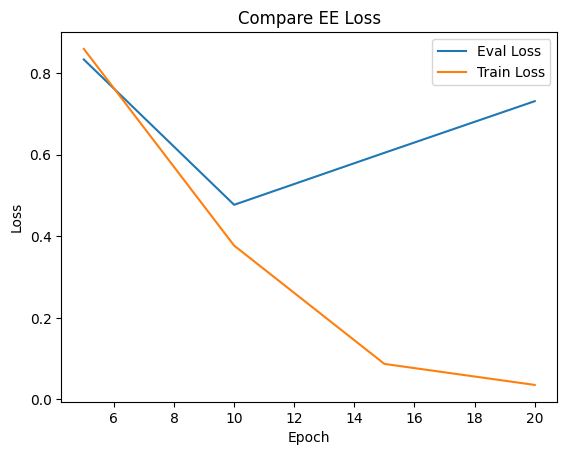

In [12]:
plt.plot(x, history["ee_eval_loss"], label="Eval Loss")
plt.plot(x, history["ee_loss"], label="Train Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Compare EE Loss")
plt.show()

In [13]:
model.evaluate_dataloader(eval_loader)

              precision    recall  f1-score   support

        DATE     0.8864    0.9251    0.9053      2403
    DURATION     0.6873    0.7715    0.7270       302
       EVENT     0.9866    0.9868    0.9867     16900
         SET     0.6471    0.6875    0.6667        16
        TIME     0.4923    0.6809    0.5714        47

   micro avg     0.9669    0.9750    0.9709     19668
   macro avg     0.7399    0.8104    0.7714     19668
weighted avg     0.9683    0.9750    0.9715     19668

              precision    recall  f1-score   support

         0.0     0.9900    0.8394    0.9085     88218
         1.0     0.1309    0.7399    0.2224      2883

    accuracy                         0.8363     91101
   macro avg     0.5604    0.7896    0.5654     91101
weighted avg     0.9628    0.8363    0.8868     91101

              precision    recall  f1-score   support

       AFTER     0.9066    0.9161    0.9113      6547
      BEFORE     0.7726    0.6863    0.7269       510
    CONTAINS     0.55

{'ner_f1': 0.9709121288068657,
 'et_f1': 0.8362586579730189,
 'ee_f1': 0.841062898089172,
 'eval_loss': 1.5297150643248307,
 'ner_loss': 0.026832570223823973,
 'et_loss': 0.77206783231936,
 'ee_loss': 0.7308146620267316}